Form Parts of Speech (POS) taggers & Syntactic Analysers 

Import Data_2.txt file.

In [2]:
with open("Data_2.txt", "r", encoding="utf-8") as file:
    text = file.read()

print(text)

The big black dog barked at the white cat and chased away.


Tokenize the text

In [3]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

tokens = word_tokenize(text)
print(tokens)

['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']


1. POS tagging using NLTK POS Tagger

In [4]:
nltk_pos_tags = nltk.pos_tag(tokens)

print("Word\t\tPOS Tag")
print("-" * 30)

for word, tag in nltk_pos_tags:
    print(f"{word}\t\t{tag}")

Word		POS Tag
------------------------------
The		DT
big		JJ
black		JJ
dog		NN
barked		VBD
at		IN
the		DT
white		JJ
cat		NN
and		CC
chased		VBD
away		RB
.		.


2. TextBlob POS Tagger

In [5]:
import nltk
from textblob import TextBlob

textblob_pos_tags = TextBlob(text)

print("Word\t\tPOS Tag")
print("-" * 30)

for word, tag in textblob_pos_tags.tags:
    print(f"{word}\t\t{tag}")

Word		POS Tag
------------------------------
The		DT
big		JJ
black		JJ
dog		NN
barked		VBD
at		IN
the		DT
white		JJ
cat		NN
and		CC
chased		VBD
away		RB


3. Regular Expression POS Tagger

In [6]:
patterns = [
    (r'^-?[0-9]+(\.[0-9]+)?$', 'CD'),  # numbers
    (r'.*ing$', 'VBG'),                # gerund verbs
    (r'.*ed$', 'VBD'),                 # past tense verbs
    (r'.*ly$', 'RB'),                  # adverbs
    (r'.*ful$', 'JJ'),                 # adjectives
    (r'.*ous$', 'JJ'),                 # adjectives
    (r'.*s$', 'NNS'),                  # plural nouns
    (r'.*', 'NN')                      # default noun
]

regexp_tagger = nltk.RegexpTagger(patterns)

regexp_pos_tags = regexp_tagger.tag(tokens)

print("Word\t\tPOS Tag")
print("-" * 30)

for word, tag in regexp_pos_tags:
    print(f"{word}\t\t{tag}")

Word		POS Tag
------------------------------
The		NN
big		NN
black		NN
dog		NN
barked		VBD
at		NN
the		NN
white		NN
cat		NN
and		NN
chased		VBD
away		NN
.		NN


Parse Tree using NLTK

Number of possible parse trees: 1

Parse Tree 1
(S
  (NP (Det The) (Adj big) (Adj black) (N dog))
  (VP
    (VBD barked)
    (PP (P at) (NP (Det the) (Adj white) (N cat)))
    (CC and)
    (VP (VBD chased) (Adv away)))
  (Punct .))


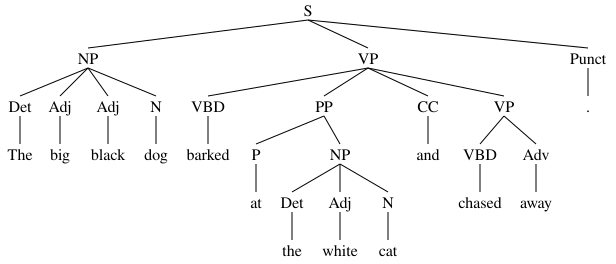

In [7]:
import nltk
from nltk import CFG
import svgling
from IPython.display import display

# define a context-free grammar (CFG) for a simple sentence structure
grammar = CFG.fromstring("""
S -> NP VP Punct

NP -> Det Adj Adj N
NP -> Det Adj N

VP -> VBD PP CC VP
VP -> VBD Adv

PP -> P NP

Det -> 'The' | 'the'
Adj -> 'big' | 'black' | 'white'
N -> 'dog' | 'cat'
VBD -> 'barked' | 'chased'
P -> 'at'
CC -> 'and'
Adv -> 'away'
Punct -> '.'
""")

# Parser
parser = nltk.ChartParser(grammar)

# Generate and print parse trees
trees = list(parser.parse(tokens))

print("Number of possible parse trees:", len(trees))

for number, tree in enumerate(trees, start=1):
    print(f"\nParse Tree {number}")
    print(tree)
    display(svgling.draw_tree(tree))
    